In [1]:
import pandas as pd
df = pd.read_csv('benin_gdelt_raw.csv')

In [2]:
df

,SQLDATE,DATEADDED,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,Actor2Type1Code,...,GoldsteinScale,AvgTone,NumMentions,NumSources,NumArticles,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20250102,20260102014500,202501,2025,UNITED KINGDOM,GBR,NaN,NIGERIA,NGA,NaN,...,1.0,-5.934066,2,1,2,Benin,BN,9.50000,2.25000,https://punchng.com/obasekis-ally-house-burnt-...
1,20250307,20260307140000,202503,2025,NaN,NaN,NaN,NIGERIAN,NGA,NaN,...,-10.0,-5.817610,10,1,10,"Borgou, Borgou, Benin",BN,9.75000,2.75000,http://www.nigeriasun.com/news/278907556/benin...
2,20250124,20260124103000,202501,2025,HOSPITAL,NaN,HLH,SENATE,NaN,LEG,...,1.9,-0.899281,10,1,10,Benin,BN,9.50000,2.25000,https://punchng.com/senator-decries-poor-state...
3,20250124,20260124103000,202501,2025,LAWMAKER,NaN,LEG,HOSPITAL,NaN,HLH,...,0.0,-0.899281,10,1,10,Benin,BN,9.50000,2.25000,https://punchng.com/senator-decries-poor-state...
4,20250124,20260124103000,202501,2025,SENATE,NaN,LEG,HOSPITAL,NaN,HLH,...,2.8,-0.899281,10,1,10,Benin,BN,9.50000,2.25000,https://punchng.com/senator-decries-poor-state...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31499,20250604,20250604211500,202506,2025,CONGO,COG,NaN,FRENCH,FRA,NaN,...,3.4,0.564972,2,1,2,Benin,BN,9.50000,2.25000,https://fr.allafrica.com/stories/202506040558....
31500,20250604,20250604191500,202506,2025,NIAMEY,NER,NaN,COTONOU,BEN,NaN,...,-2.0,-0.746269,10,1,10,"Niamey, Niamey, Niger",NG,13.51670,2.11667,https://www.koaci.com/article/2025/06/04/niger...
31501,20250604,20250604103000,202506,2025,OPERATIVE,NaN,SPY,BENIN,BEN,NaN,...,6.4,-0.165017,3,1,3,"Ikeja, Lagos, Nigeria",NI,6.59422,3.33748,https://www.legit.ng/business-economy/money/16...
31502,20250604,20250604103000,202506,2025,BENIN,BEN,NaN,COLLEGE,NaN,EDU,...,3.4,-0.165017,2,1,2,Benin,BN,9.50000,2.25000,https://www.legit.ng/business-economy/money/16...


In [3]:
df.columns

Index(['SQLDATE', 'DATEADDED', 'MonthYear', 'Year', 'Actor1Name',
       'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2Type1Code', 'IsRootEvent', 'EventCode',
       'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale',
       'AvgTone', 'NumMentions', 'NumSources', 'NumArticles',
       'ActionGeo_FullName', 'ActionGeo_CountryCode', 'ActionGeo_Lat',
       'ActionGeo_Long', 'SOURCEURL'],
      dtype='object')

In [4]:
df.shape

(31504, 25)

In [6]:
# Convertit la Series en DataFrame d'une seule colonne
df1 = df['EventCode'].value_counts().to_frame()
df1

,count
EventCode,
10,3186
42,3032
51,2939
43,2823
20,1772
...,...
256,1
1233,1
1822,1


In [9]:
daily.nlargest(10, 'NumArticles')

,NumArticles,NumMentions
date,,
2025-12-07,5653,5720
2025-12-08,5431,5470
2025-12-09,3636,3665
2025-12-10,1936,1947
2025-12-12,1827,1870
2025-12-11,1467,1467
2025-01-10,1377,1403
2025-04-17,1335,1374
2025-02-19,1221,1233


In [11]:
df[['AvgTone','GoldsteinScale']].describe()

,AvgTone,GoldsteinScale
count,31504.000000,31504.000000
mean,-1.369124,0.682507
std,4.483653,4.623996
min,-18.518519,-10.000000
25%,-4.524887,-2.000000
50%,-1.297297,1.900000
75%,1.871762,3.400000
max,19.480519,10.000000


In [ ]:
df['event_date'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df['mention_date'] = pd.to_datetime(df['DATEADDED'], format='%Y%m%d%H%M%S')
df['delay'] = (df['mention_date'] - df['event_date']).dt.days

In [ ]:
df['delay'].describe()

count    31504.000000
mean         0.680517
std         15.129021
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        365.000000
Name: delay, dtype: float64

In [ ]:
print(df['EventRootCode'].unique())

[ 4 19  1  8  5 18 17  2  9 11  6  7 10 14 12  3 13 15 16]


In [ ]:
df['crisis'] = df['EventRootCode'].isin([14, 18, 19])

In [ ]:
df['crisis'].value_counts()

crisis
False    28767
True      2737
Name: count, dtype: int64

In [ ]:
df.groupby(['crisis'])['NumSources'].mean()

crisis
False    1.011437
True     1.013884
Name: NumSources, dtype: float64

In [ ]:
df[df['crisis'] == True]['SOURCEURL'].value_counts().head(10)

SOURCEURL
https://blueprint.ng/fg-to-open-another-ddr-camp-for-low-risk-terrorists-in-northwest-gen-laka/                          12
https://www.eurasiareview.com/16072025-harmattan-hazards-how-coastal-west-africa-can-escape-the-sahels-fate-analysis/    10
https://www.ena.et/web/eng/w/eng_6479984                                                                                  9
https://www.yahoo.com/news/al-qaeda-offshoot-became-one-010501697.html                                                    9
https://www.terradaily.com/reports/Suspected_jihadist_attack_in_Benin_kills_soldiers_police_999.html                      9
https://truthnigeria.com/2025/01/sahel-sliding-into-darkness-al-qaeda-and-islamic-state-intensify-attacks/                9
https://www.spacewar.com/afp/250605222330.i2elts2j.html                                                                   9
http://www.pambazuka.org/The-Benin-Coup                                                                                   

In [ ]:
df['Benin_actor1'] = df['Actor1CountryCode'] == 'BEN'
df['Benin_actor2'] = df['Actor2CountryCode'] == 'BEN'

In [ ]:
df[['Benin_actor1','Benin_actor2']].sum()

Benin_actor1    10151
Benin_actor2     9052
dtype: int64

In [ ]:
initiator = df['Benin_actor1'].sum()
receiver = df['Benin_actor2'].sum()

In [ ]:
df.head()

,SQLDATE,DATEADDED,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,Actor2Type1Code,...,ActionGeo_Lat,ActionGeo_Long,SOURCEURL,date,event_date,mention_date,delay,crisis,Benin_actor1,Benin_actor2
0,20250102,20260102014500,202501,2025,UNITED KINGDOM,GBR,NaN,NIGERIA,NGA,NaN,...,9.50,2.25,https://punchng.com/obasekis-ally-house-burnt-...,2025-01-02,2025-01-02,2026-01-02 01:45:00,365,False,False,False
1,20250307,20260307140000,202503,2025,NaN,NaN,NaN,NIGERIAN,NGA,NaN,...,9.75,2.75,http://www.nigeriasun.com/news/278907556/benin...,2025-03-07,2025-03-07,2026-03-07 14:00:00,365,True,False,False
2,20250124,20260124103000,202501,2025,HOSPITAL,NaN,HLH,SENATE,NaN,LEG,...,9.50,2.25,https://punchng.com/senator-decries-poor-state...,2025-01-24,2025-01-24,2026-01-24 10:30:00,365,False,False,False
3,20250124,20260124103000,202501,2025,LAWMAKER,NaN,LEG,HOSPITAL,NaN,HLH,...,9.50,2.25,https://punchng.com/senator-decries-poor-state...,2025-01-24,2025-01-24,2026-01-24 10:30:00,365,False,False,False
4,20250124,20260124103000,202501,2025,SENATE,NaN,LEG,HOSPITAL,NaN,HLH,...,9.50,2.25,https://punchng.com/senator-decries-poor-state...,2025-01-24,2025-01-24,2026-01-24 10:30:00,365,False,False,False


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Conversion des dates
df['date'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df['mention_date'] = pd.to_datetime(df['DATEADDED'], format='%Y%m%d%H%M%S', errors='coerce')

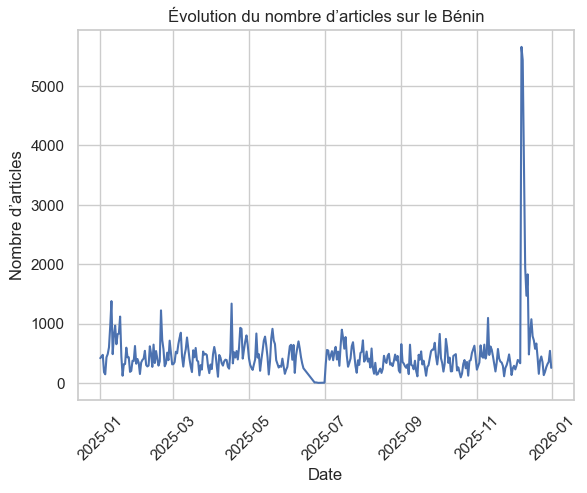

In [ ]:
daily = df.groupby('date')['NumArticles'].sum().reset_index()

plt.figure()
sns.lineplot(data=daily, x='date', y='NumArticles')
plt.title("Évolution du nombre d’articles sur le Bénin")
plt.xlabel("Date")
plt.ylabel("Nombre d’articles")
plt.xticks(rotation=45)
plt.show()

# Quand le monde parle-t-il du Bénin, et quels événements provoquent les pics de couverture ? 


### Ce graphique présente l'évolution du nombre de d'articles sur le Bénin au cours de l'année 2025. Il ressort de son exploitation que le volume d'articles oscillent entre 50 et 100 articles. Ceci témoigne d'une activité diplomatique et sociale constante. Cependant, l'explosion massive observée vers la fin de l'année 2025 (plus de 5000 articles) signale un événement de rupture majeure qui à susciter une attention particulière dans l'opinion publique aussi bien à l'intérieur qu'à l'extérieur.



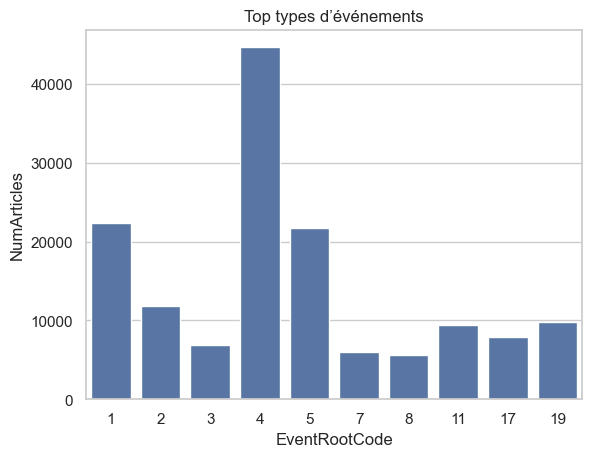

In [ ]:
events = df.groupby('EventRootCode')['NumArticles'].sum().reset_index()

events = events.sort_values(by='NumArticles', ascending=False).head(10)

plt.figure()
sns.barplot(data=events, x='EventRootCode', y='NumArticles')
plt.title("Top types d’événements")
plt.show()

### Ce graphique présente les sujets les plus discutés pendant l'année 2025. Le code 04 écrase littéralement toutes les autres catégories avec plus de 40 000 articles. Dans le système GDELT, le code 04 correspond aux consultations, visites diplomatiques et rencontres officielles. Cela montre que l'actualité du Bénin est massivement dictée par l'activité institutionnelle et diplomatique. Le Bénin est donc perçu comme un terrain de dialogue et de rencontres. Les codes 01 (Déclarations publiques) et 05 (Coopération diplomatique/économique) arrivent en deuxième position avec environ 20 000 articles chacun. Ceci confirme un climat majoritairement tourné vers la vie politique "normale" et les relations extérieures. Bien que minoritaire par rapport aux visites officielles, le code 19 (Combats/Usage de la force) est bien visible sur le graphique, approchant les 10 000 articles. Même si ces événements sont moins fréquents que les discours, ils génèrent un volume d'articles non négligeable, ce qui montre leur fort impact médiatique.

# Le ton médiatique mondial sur le Bénin est-il positif, neutre ou négatif et comment évolue t-il?

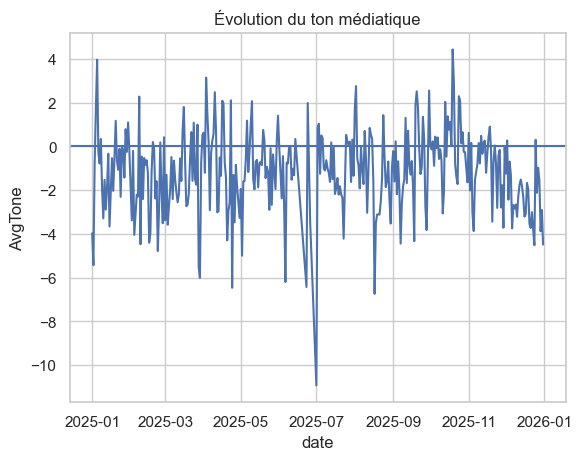

In [ ]:
tone = df.groupby('date')['AvgTone'].mean().reset_index()

plt.figure()
sns.lineplot(data=tone, x='date', y='AvgTone')
plt.axhline(0)
plt.title("Évolution du ton médiatique")
plt.show()

### Ce graphique présente l'évolution du ton médiatique au cours de l'année 2025. Son analyse révèle une prédominance du ton négatif. La majorité de la courbe évolue en dessous de la ligne du 0 (la zone neutre). Cela indique que le traitement médiatique global au cours de l'année 2025 est majoritairement teinté de négativité (un ton négatif étant souvent lié à des rapports de conflits, des problèmes sociaux ou des tensions politiques). En Juillet 2025, on observe un "décrochage" spectaculaire, où le ton chute sous la barre des -10. C'est le moment le plus critique de l'année sur le plan du sentiment. Il est intéressant de noter que ce pic de négativité survient juste après le "trou de données" de juin que nous avions vu sur le graphique précédent. Cela pourrait signifier qu'une crise majeure a éclaté juste après cette rupture, provoquant un choc médiatique intense. La courbe est extrêmement "déchiquetée" avec des variations rapides entre le positif et le négatif. Cette forte volatilité montre que l'actualité au Bénin est très réactive. Le sentiment change d'un jour à l'autre, ce qui confirme l'utilité d'un dashboard en temps réel pour les décideurs : une situation peut paraître stable le lundi et devenir critique le mardi.

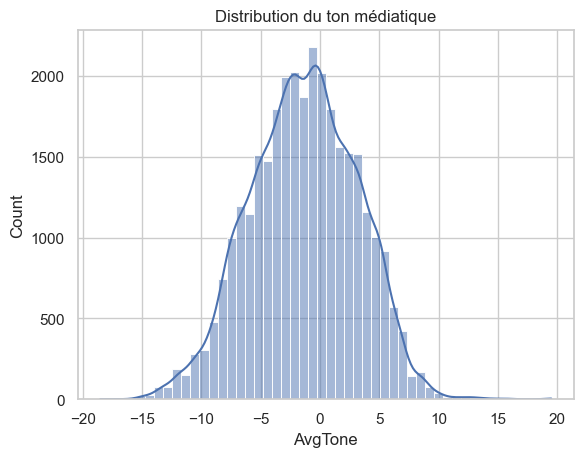

In [ ]:
plt.figure()
sns.histplot(df['AvgTone'], bins=50, kde=True)
plt.title("Distribution du ton médiatique")
plt.xlabel("AvgTone")
plt.show()

### Ce graphique présente la distribution du ton médiatique des événements enregistrés dans le jeu de données. Ce graphique montre une distribution qui ressemble fortement à une courbe normale, centrée autour de 0, avec un pic d'environ 2 100 occurrences. La grande majorité des événements sont donc couverts avec un ton neutre ou légèrement négatif. On observe cependant que la distribution est légèrement asymétrique vers la gauche. Cela signifie que les tons négatifs sont un peu plus fréquents que les tons positifs, ce qui traduit une tendance générale des médi*as à couvrir les événements liés au Bénin avec une légère coloration négative. Les valeurs extrêmes en dessous de -10 et au-dessus de 10 existent mais restent très rares. Les tons très négatifs ou très positifs représentent donc des cas isolés dans ce jeu de données. À partir de -10 et de +10, les barres deviennent quasiment invisibles à cette échelle. Globalement, le ton médiatique est majoritairement neutre à légèrement négatif. Cela peut refléter la nature des événements couverts souvent des faits politiques, sécuritaires ou économiques qui sont rarement traités de manière très enthousiaste ou très alarmiste. Cette distribution relativement équilibrée est un bon signe pour les analyses, car elle évite les biais liés à une surreprésentation de tons extrêmes.

In [ ]:
df['delay'] = (df['mention_date'] - df['date']).dt.days

# Combien de jours faut-il pour que la couverture médiatique atteigne son pic après un évènement ?

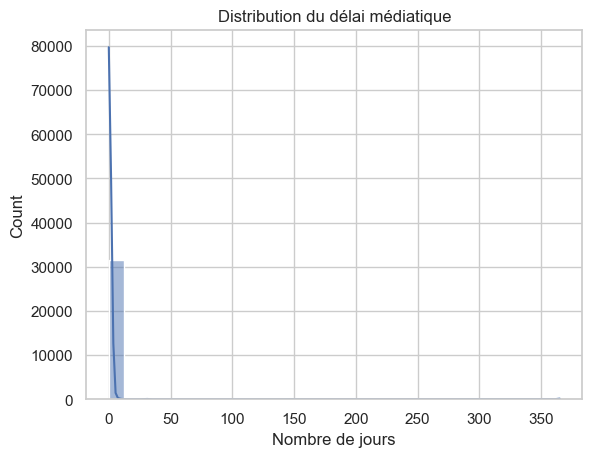

In [ ]:
plt.figure()
sns.histplot(df['delay'], bins=30, kde=True)
plt.title("Distribution du délai médiatique")
plt.xlabel("Nombre de jours")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(0, df['delay'].max() + 5, 5)

df['tranche'] = pd.cut(df['delay'], bins=bins, right=False)

df_counts = df['tranche'].value_counts().sort_index().reset_index()
df_counts.columns = ['Tranche', 'Nombre']

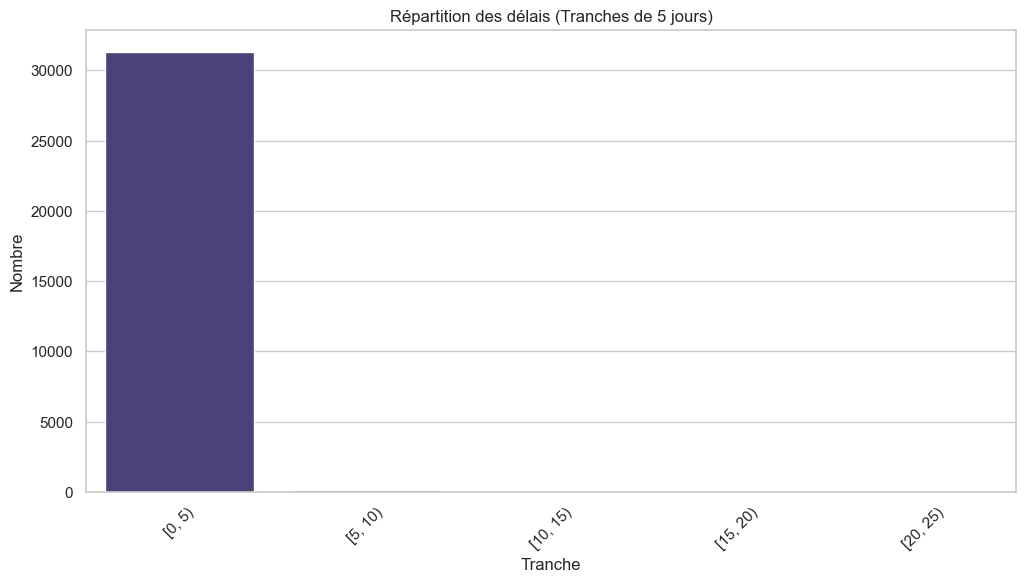

In [ ]:
df_zoom = df_counts.head(5).copy()

df_zoom['Tranche'] = df_zoom['Tranche'].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_zoom, 
    x='Tranche', 
    y='Nombre', 
    hue='Tranche',     
    palette='viridis', 
    legend=False       
)

plt.xticks(rotation=45)
plt.title('Répartition des délais (Tranches de 5 jours)')
plt.show()

### Ce graphique présente la répartition du délai de circulation de l'information par tranche de 5 jours. Le graphique montre une domination absolue de la première tranche, à savoir entre 0 et 5 jours. La quasi-totalité des événements (plus de 30 000 évènements) sont traités ou rapportés dans un délai inférieur à 5 jours. Cela démontre une très grande vitesse de circulation de l'information dans ton jeu de données. À partir de la tranche de 5 à 10 jours, les barres deviennent quasiment invisibles à cette échelle. Une fois passé le cap des 5 premiers jours, l'intérêt médiatique ou le traitement des données chute drastiquement. L'information a donc un caractère "périssable" c'est à dire qu'elle est soit traitée instantanément ou soit elle tombe rapidement dans l'oubli ou le silence.

plt.figure()
sns.boxplot(x=df['delay'])
plt.title("Dispersion du délai")
plt.show()

<Axes: xlabel='crisis', ylabel='count'>

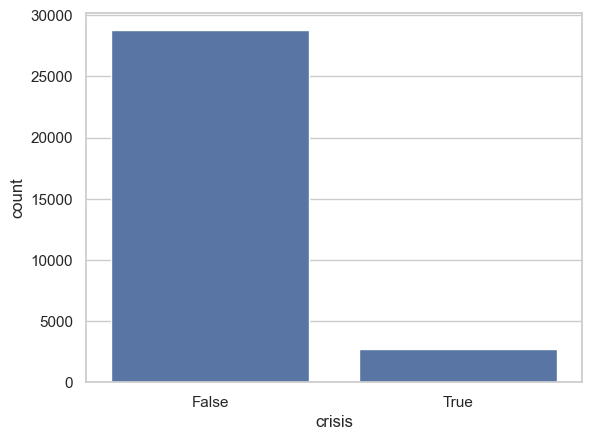

In [ ]:
sns.countplot(data=df, x='crisis')

### Ce graphique présente la répartition des événements selon qu'ils sont liés ou non à une situation de crise. Le graphique montre une domination absolue des événements non liés à une crise (False), avec environ 28 500 occurrences, contre seulement environ 2 500 pour les événements de crise (True). La grande majorité des événements enregistrés dans ce jeu de données ne sont donc pas des situations de crise. Cela démontre que les crises représentent une part minoritaire des événements couverts, soit environ 8 % du total. L'écart entre les deux catégories est très marqué, ce qui traduit un jeu de données fortement déséquilibré entre événements ordinaires et événements de crise. Ce déséquilibre est un élément important à prendre en compte, notamment si ce jeu de données est utilisé pour entraîner un modèle de classification. Un tel déséquilibre entre les classes peut conduire le modèle à privilégier systématiquement la classe majoritaire (False) et à mal détecter les situations de crise réelles. Des techniques de rééquilibrage comme le sur-échantillonnage ou le sous-échantillonnage seraient alors à envisager.

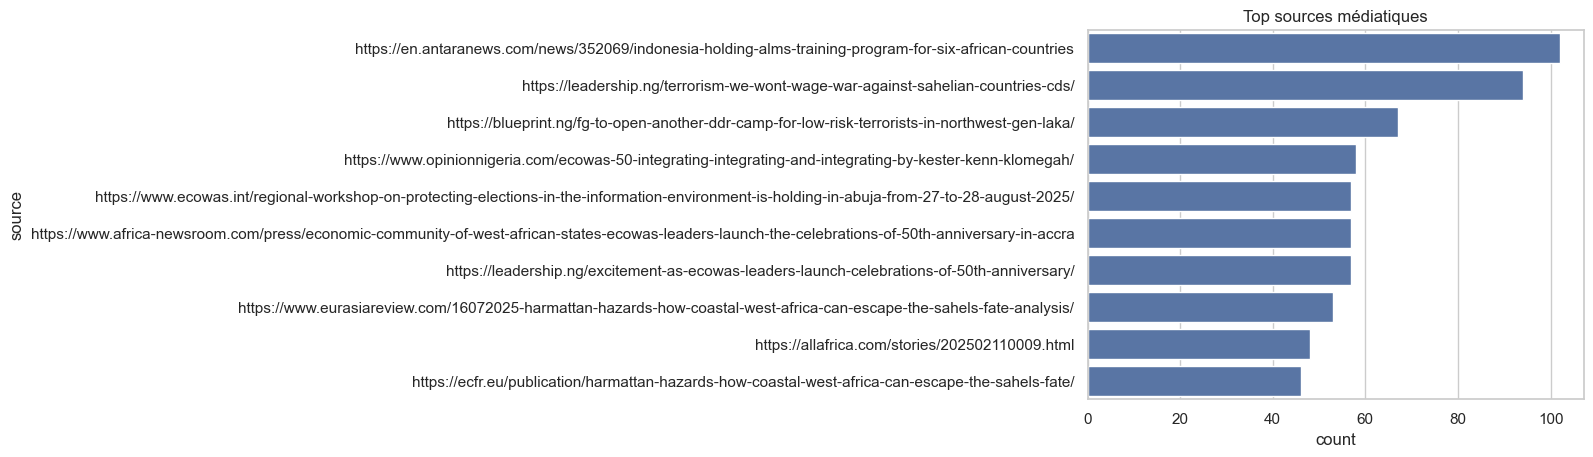

In [ ]:
top_sources = df['SOURCEURL'].value_counts().head(10).reset_index()
top_sources.columns = ['source', 'count']

plt.figure()
sns.barplot(data=top_sources, y='source', x='count')
plt.title("Top sources médiatiques")
plt.show()

### Ce graphique présente les principales sources médiatiques classées selon le nombre d'articles publiés. Le graphique montre une concentration très forte de la production d'information autour d'un petit nombre d'acteurs. Une seule source se détache nettement avec un volume d'articles largement supérieur à toutes les autres. Cela peut traduire soit une activité éditoriale particulièrement intense de cette source, soit un biais dans la collecte des données. Derrière ce premier acteur, un groupe de médias notamment d'Afrique de l'Ouest contribue de manière significative mais bien plus modérée, ce qui suggère une focalisation régionale des événements couverts. Les sources restantes apparaissent avec des volumes très faibles, traduisant une participation marginale ou spécialisée. Globalement, la distribution est très inégale. L'information est donc majoritairement produite par un nombre restreint d'acteurs. Cette concentration n'est pas sans conséquence : si elle n'est pas prise en compte, elle peut influencer, voire biaiser, l'interprétation des analyses qui en découlent.

In [ ]:
df['Benin_actor1'] = df['Actor1CountryCode'] == 'BEN'
df['Benin_actor2'] = df['Actor2CountryCode'] == 'BEN'

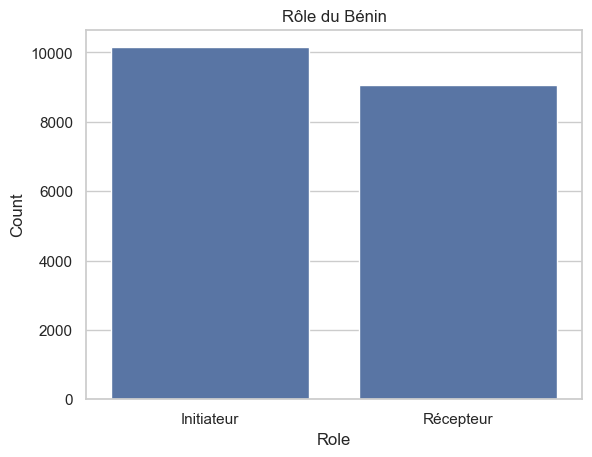

In [ ]:
roles = pd.DataFrame({
    'Role': ['Initiateur', 'Récepteur'],
    'Count': [
        df['Benin_actor1'].sum(),
        df['Benin_actor2'].sum()
    ]
})

plt.figure()
sns.barplot(data=roles, x='Role', y='Count')
plt.title("Rôle du Bénin")
plt.show()

### Ce graphique présente la répartition du rôle joué par le Bénin dans les événements enregistrés, en distinguant deux positions : Initiateur et Récepteur. Le graphique montre que le Bénin agit légèrement plus souvent comme Initiateur, avec environ 10 200 occurrences, contre environ 9 100 pour le rôle de Récepteur. Les deux barres sont cependant assez proches l'une de l'autre. Cela démontre que le Bénin n'est pas cantonné à un rôle passif dans les événements couverts. Il prend l'initiative dans une proportion légèrement supérieure, ce qui traduit une certaine activité diplomatique, politique ou sécuritaire de sa part dans les interactions enregistrées. L'écart entre les deux rôles est relativement faible, de l'ordre de 1 000 occurrences. La distribution est donc globalement équilibrée, ce qui est un résultat intéressant : le Bénin est autant un acteur qui agit qu'un acteur qui reçoit des actions de la part de ses partenaires. Cette quasi-parité suggère que le pays occupe une position dynamique dans son environnement régional, sans être ni totalement dominant ni totalement passif dans les interactions médiatiquement couvertes.

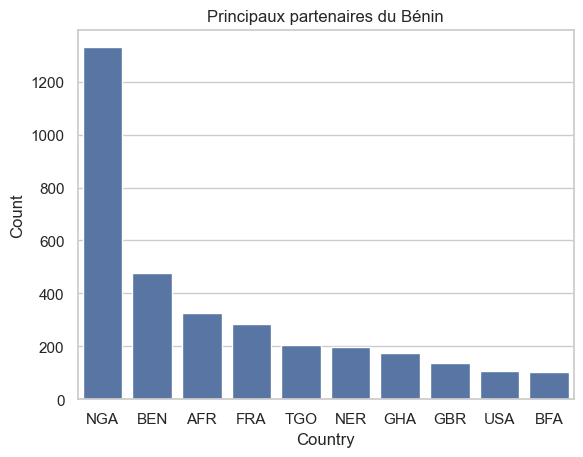

In [ ]:
partners = df[df['Actor1CountryCode']=='BEN']['Actor2CountryCode'].value_counts().head(10).reset_index()
partners.columns = ['Country', 'Count']

plt.figure()
sns.barplot(data=partners, x='Country', y='Count')
plt.title("Principaux partenaires du Bénin")
plt.show()

### Ce graphique présente les principaux partenaires du Bénin classés selon le nombre d'interactions ou d'événements enregistrés. Le graphique montre une domination absolue du Nigeria (NGA), avec un comptage d'environ 1 300, ce qui le place très loin devant tous les autres partenaires. Cela démontre que le Nigeria est de loin le partenaire le plus impliqué dans les événements concernant le Bénin dans ce jeu de données. Derrière le Nigeria, le Bénin lui-même apparaît en deuxième position avec environ 480 occurrences, ce qui peut s'expliquer par des événements impliquant des acteurs internes au pays. L'Afrique au sens large et la France suivent avec respectivement environ 330 et 285 occurrences, traduisant une présence régionale et une influence historique notable. Les partenaires comme le Togo, le Niger, le Ghana, le Royaume-Uni, les États-Unis et le Burkina Faso affichent tous des valeurs comprises entre 100 et 210, avec des écarts relativement faibles entre eux. Leur présence reste significative mais bien plus modérée. Globalement, la distribution est très inégale et dominée par un seul acteur. Le Nigeria concentre à lui seul une part disproportionnée des interactions, ce qui reflète le poids géopolitique et géographique de ce pays vis-à-vis du Bénin.